In [ ]:
# TODO: current 4.59 it/s
# TODO: word tokenizer
# TODO: visualize attention
# TODO: visualize gradient issues
# TODO: without bias?
# TODO: make sampling faster
# TODO: how to measure model quality?
# TODO: karpathy tokenizer video
# TODO: add validation set / step
# TODO: load gpt 2 checkpoint 

CONFIG = {
    "seq_len": 128, # TODO: call block_size
    "batch_size": 128,
    "embed_size": 64, #
    "num_heads": 2, # TODO: why can't I use 6 heads?
    "num_layers": 4,
    "learning_rate": 3e-4,
    "max_steps": 500,
    #"dropout": 0.1,
    "layer_norm_enabled": True,
}

"""
CONFIG = {
    "seq_len": 128,  # Increased from 10 - critical for learning context
    "batch_size": 64,  # Increased from 4 - better gradient estimates
    "embed_size": 128,  # Increased from 32 - more model capacity
    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)
    "num_layers": 4,  # Increased from 2 - deeper model for better learning
    "dropout": 0.1,  # Enable dropout for regularization
    "learning_rate": 3e-4,  # Standard for transformers (AdamW)
    "weight_decay": 0.1,  # L2 regularization
    "max_steps": 1000,  # More training steps
}
"""


'\nCONFIG = {\n    "seq_len": 128,  # Increased from 10 - critical for learning context\n    "batch_size": 64,  # Increased from 4 - better gradient estimates\n    "embed_size": 128,  # Increased from 32 - more model capacity\n    "num_heads": 4,  # Increased from 2 - better attention patterns (embed_size must be divisible)\n    "num_layers": 4,  # Increased from 2 - deeper model for better learning\n    "dropout": 0.1,  # Enable dropout for regularization\n    "learning_rate": 3e-4,  # Standard for transformers (AdamW)\n    "weight_decay": 0.1,  # L2 regularization\n    "max_steps": 1000,  # More training steps\n}\n'

In [2]:
import torch
DEVICE = torch.device("mps")

Load dataset:

In [3]:
import requests
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATASET_TEXT = requests.get(url).text
print("n_tokens", len(DATASET_TEXT))

n_tokens 1115394


In [4]:
with open("data/lotr.txt", "r", encoding="latin-1") as f: DATASET_TEXT = f.read()

In [5]:
chars = sorted(list(set(DATASET_TEXT)))
len(chars), chars

(89,
 ['\t',
  '\n',
  ' ',
  '!',
  '"',
  "'",
  '(',
  ')',
  '*',
  ',',
  '-',
  '.',
  '/',
  '0',
  '1',
  '2',
  '3',
  '4',
  '5',
  '6',
  '7',
  '8',
  '9',
  ':',
  ';',
  '=',
  '?',
  'A',
  'B',
  'C',
  'D',
  'E',
  'F',
  'G',
  'H',
  'I',
  'J',
  'K',
  'L',
  'M',
  'N',
  'O',
  'P',
  'Q',
  'R',
  'S',
  'T',
  'U',
  'V',
  'W',
  'X',
  'Y',
  'Z',
  'a',
  'b',
  'c',
  'd',
  'e',
  'f',
  'g',
  'h',
  'i',
  'j',
  'k',
  'l',
  'm',
  'n',
  'o',
  'p',
  'q',
  'r',
  's',
  't',
  'u',
  'v',
  'w',
  'x',
  'y',
  'z',
  'Ó',
  'á',
  'â',
  'ä',
  'é',
  'ë',
  'í',
  'ó',
  'ú',
  'û'])

Create tokenizer:

In [6]:
ctoi = {c:i for i, c in enumerate(chars)}
itoc = {i:c for i, c in enumerate(chars)}
encode = lambda text: [ctoi[c] for c in text]
decode = lambda tokens: "".join([itoc[i] for i in tokens])
decode(encode("hello world"))

'hello world'

Create token embedding table:

In [7]:
import torch
import torch.nn as nn

vocab_size = len(ctoi)
embed_size = CONFIG["embed_size"]
CONFIG["vocab_size"] = vocab_size

seq_len = CONFIG["seq_len"]
pad = lambda text: " " * max(0, seq_len - len(text)) + text
text = pad("hello")
tokens = torch.tensor(encode(text))
token_embedding_table = nn.Embedding(vocab_size, embed_size)
tokens_emb = token_embedding_table(tokens)
tokens_emb.shape, tokens_emb

(torch.Size([128, 64]),
 tensor([[ 1.7491, -0.8757, -0.1412,  ..., -0.2508, -1.6176,  2.1980],
         [ 1.7491, -0.8757, -0.1412,  ..., -0.2508, -1.6176,  2.1980],
         [ 1.7491, -0.8757, -0.1412,  ..., -0.2508, -1.6176,  2.1980],
         ...,
         [-1.4044, -1.5453,  0.8128,  ..., -0.7218, -1.0060,  0.7983],
         [-1.4044, -1.5453,  0.8128,  ..., -0.7218, -1.0060,  0.7983],
         [-0.3457, -0.0779,  0.6726,  ...,  0.1772,  0.5480,  1.6091]],
        grad_fn=<EmbeddingBackward0>))

Create position embedding table:

In [8]:
seq_len = CONFIG["seq_len"]
embed_size = CONFIG["embed_size"]

position_embedding_table = nn.Embedding(seq_len, embed_size)
positions = torch.arange(seq_len)
positions_emb = position_embedding_table(positions)
positions_emb.shape, positions_emb

(torch.Size([128, 64]),
 tensor([[-0.2534,  0.3875, -0.3809,  ..., -0.0541,  1.4277,  0.3808],
         [-1.5136, -0.5617,  1.7927,  ..., -0.7448, -0.1457, -1.5175],
         [ 2.0316,  0.1162, -1.3994,  ..., -0.8771,  0.0766, -0.5701],
         ...,
         [ 0.8328,  0.5486,  1.7536,  ...,  0.3297, -1.0673,  0.1981],
         [ 0.0262, -1.1933, -0.7365,  ...,  0.0846, -1.2173, -1.1464],
         [ 0.0870,  1.4119,  0.9634,  ..., -0.5628, -0.5295, -0.7305]],
        grad_fn=<EmbeddingBackward0>))

Test combining token embeddings and positions embeddings:

In [9]:
x = tokens_emb + positions_emb
x.shape, x

(torch.Size([128, 64]),
 tensor([[ 1.4957, -0.4882, -0.5221,  ..., -0.3049, -0.1899,  2.5788],
         [ 0.2355, -1.4375,  1.6515,  ..., -0.9956, -1.7633,  0.6805],
         [ 3.7806, -0.7596, -1.5405,  ..., -1.1279, -1.5410,  1.6279],
         ...,
         [-0.5716, -0.9967,  2.5664,  ..., -0.3922, -2.0733,  0.9965],
         [-1.3782, -2.7387,  0.0763,  ..., -0.6372, -2.2233, -0.3481],
         [-0.2587,  1.3340,  1.6360,  ..., -0.3856,  0.0184,  0.8787]],
        grad_fn=<AddBackward0>))

Create batch sampler:

In [10]:
DATASET_TOKENS = encode(DATASET_TEXT)

def sample_batch(batch_len):
    seq_len = CONFIG["seq_len"]
    xs, ys = [], []
    for _ in range(batch_len):
        offset_idx = torch.randint(len(DATASET_TOKENS) - seq_len, (1,))
        x = DATASET_TOKENS[offset_idx:offset_idx+seq_len]
        y = DATASET_TOKENS[offset_idx+1:offset_idx+seq_len+1]
        xs.append(x)
        ys.append(y)
    return torch.tensor(xs), torch.tensor(ys)

x, y = sample_batch(10)
x.shape, x, y.shape, y


(torch.Size([10, 128]),
 tensor([[70, 53, 55,  ..., 72,  2, 77],
         [71, 72, 67,  ...,  9,  2, 58],
         [ 2, 63, 66,  ..., 71, 71,  2],
         ...,
         [67,  2, 54,  ..., 53, 54, 64],
         [77,  2, 55,  ..., 72, 60, 53],
         [53, 77,  9,  ..., 70, 61, 66]]),
 torch.Size([10, 128]),
 tensor([[53, 55, 77,  ...,  2, 77, 67],
         [72, 67, 66,  ...,  2, 58, 53],
         [63, 66, 67,  ..., 71,  2, 59],
         ...,
         [ 2, 54, 53,  ..., 54, 64, 57],
         [ 2, 55, 60,  ..., 60, 53, 72],
         [77,  9,  2,  ..., 61, 66, 59]]))

Test decoding batch:

In [11]:
for i in range(x.shape[0]):
    x_tokens = x[i].tolist()
    y_tokens = y[i].tolist()
    print(f"x {i}: {decode(x_tokens)}")
    print(f"y {i}: {decode(y_tokens)}")
    print()

x 0: racy," said Frodo. "But what about the Black Riders? Would it be safe to wait one day for Gandalf?"
	"That all depends on what y
y 0: acy," said Frodo. "But what about the Black Riders? Would it be safe to wait one day for Gandalf?"
	"That all depends on what yo

x 1: stones of the hills straight towards the Mountains.
	Goldberry spoke to them and recalled their eyes and thoughts. "Speed now, f
y 1: tones of the hills straight towards the Mountains.
	Goldberry spoke to them and recalled their eyes and thoughts. "Speed now, fa

x 2:  known and seen of him came clear before their minds. As they were healed of hurt and weariness of body the grief of their loss 
y 2: known and seen of him came clear before their minds. As they were healed of hurt and weariness of body the grief of their loss g

x 3: will send my people to you in the morning to help you make ready for the journey. Now we will wish you all a fair night and untr
y 3: ill send my people to you in the morning to help you m

In [12]:
batch_size = CONFIG["batch_size"]
seq_len = CONFIG["seq_len"]
x, _ = sample_batch(batch_size)
x_emb = token_embedding_table(x)
positions = torch.arange(seq_len)
pos_emb = position_embedding_table(positions)
x = x_emb + pos_emb
x.shape, x[0][0]

(torch.Size([128, 128, 64]),
 tensor([ 0.5315,  0.9254, -0.9087,  0.5676,  0.5093, -1.6065, -0.8067,  1.4752,
         -0.0516, -0.6399, -1.7743, -0.5129, -0.2215,  0.8323, -0.6078,  0.4408,
          0.3357, -0.3538,  0.1117, -1.7339,  1.1992,  0.0493, -2.0329,  0.7883,
         -2.1090,  1.7422, -0.8364,  1.3802, -0.2790,  2.5617, -0.0077,  0.1326,
         -1.4230, -0.2725, -2.8271,  0.1719, -1.2485,  0.7826,  1.4107,  0.9485,
         -0.9733,  2.4376, -0.1868,  1.9437, -2.3067,  1.2424,  1.1321,  0.8307,
         -0.5805,  1.5244,  1.0052, -3.1804,  1.1508,  0.8189, -1.1448, -3.0702,
         -0.2460, -0.1286, -1.2962,  0.2915,  0.8982, -0.1127,  0.8821,  0.5845],
        grad_fn=<SelectBackward0>))

In [13]:
qkv_shape = (CONFIG["embed_size"], CONFIG["embed_size"]) # TODO; call embed_dim
Wq = torch.randn(qkv_shape)
Wk = torch.randn(qkv_shape)
Wv = torch.randn(qkv_shape)

In [14]:
Q = x @ Wq
K = x @ Wk
V = x @ Wv
Q.shape, K.shape, V.shape

(torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]),
 torch.Size([128, 128, 64]))

In [15]:
Kt = K.transpose(-2, -1)
Kt.shape

torch.Size([128, 64, 128])

In [16]:
QKt = Q @ Kt # (B, T, C) @ (B, C, T) -> (B, T, T)
QKt.shape, QKt[0][0]

(torch.Size([128, 128, 128]),
 tensor([  294.2975,  -473.5761,  -862.7002,   263.2694,   429.0676,  -687.1384,
           337.4642,  -509.0881,   490.5827,   -67.5674, -1385.5109, -1260.1187,
           360.8812,  -422.8839,  -229.4572,  -611.3646,  -829.1025,  -215.3197,
          -240.1978,   258.8356, -1050.7778, -1308.2534,  1781.0573,  -928.3246,
         -1199.3651,  1221.4546,  1253.8857,  1135.4252,   330.1793,   245.4246,
           179.1666,  -588.3026,  1240.4866,   327.8920,  -518.9450,   738.6631,
          1085.9587,  -461.7653,  -125.4854,    69.7931,   376.1332, -1430.4094,
           415.7305,  -329.6772,   228.7246,  -117.1563,   762.1252, -1458.2738,
         -1287.8286,  1493.7827,   727.8597,   756.7004,  -555.5196,  -944.0997,
            87.5823,    -4.2486,  -685.1165,   113.6728,   457.9102,  -175.3301,
          -125.0989,    56.5615,  -678.3085,  1277.6747,   446.5941,    60.5116,
          -447.6960, -1954.9554,  -741.4488,  1203.0729,   542.2296,  -164.8298

In [17]:
QKt_scaled = QKt / torch.sqrt(torch.tensor(embed_size))
QKt_scaled.shape, QKt_scaled[0][0]

(torch.Size([128, 128, 128]),
 tensor([  36.7872,  -59.1970, -107.8375,   32.9087,   53.6334,  -85.8923,
           42.1830,  -63.6360,   61.3228,   -8.4459, -173.1889, -157.5148,
           45.1101,  -52.8605,  -28.6821,  -76.4206, -103.6378,  -26.9150,
          -30.0247,   32.3544, -131.3472, -163.5317,  222.6322, -116.0406,
         -149.9206,  152.6818,  156.7357,  141.9281,   41.2724,   30.6781,
           22.3958,  -73.5378,  155.0608,   40.9865,  -64.8681,   92.3329,
          135.7448,  -57.7207,  -15.6857,    8.7241,   47.0167, -178.8012,
           51.9663,  -41.2097,   28.5906,  -14.6445,   95.2657, -182.2842,
         -160.9786,  186.7228,   90.9825,   94.5875,  -69.4399, -118.0125,
           10.9478,   -0.5311,  -85.6396,   14.2091,   57.2388,  -21.9163,
          -15.6374,    7.0702,  -84.7886,  159.7093,   55.8243,    7.5640,
          -55.9620, -244.3694,  -92.6811,  150.3841,   67.7787,  -20.6037,
          -13.2383,  -20.0997,    9.9268, -147.3299, -161.4758,  -96.9

In [18]:
tril = torch.tril(torch.ones((seq_len, seq_len)))
tril

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [1., 1., 0.,  ..., 0., 0., 0.],
        [1., 1., 1.,  ..., 0., 0., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 0.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [19]:
mask = tril == 0
mask

tensor([[False,  True,  True,  ...,  True,  True,  True],
        [False, False,  True,  ...,  True,  True,  True],
        [False, False, False,  ...,  True,  True,  True],
        ...,
        [False, False, False,  ..., False,  True,  True],
        [False, False, False,  ..., False, False,  True],
        [False, False, False,  ..., False, False, False]])

In [20]:
QKt_scaled_masked = QKt_scaled.masked_fill(mask, float("-inf"))
QKt_scaled_masked.shape, QKt_scaled_masked[0]

(torch.Size([128, 128, 128]),
 tensor([[  36.7872,      -inf,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ -15.3732,   40.6257,      -inf,  ...,      -inf,      -inf,
               -inf],
         [ 279.1704, -212.6925,    8.5878,  ...,      -inf,      -inf,
               -inf],
         ...,
         [ -41.6895,   -8.9159,   -6.3945,  ...,   86.8600,      -inf,
               -inf],
         [-114.2098,  140.0219,  -26.6247,  ...,   62.6371,   97.5276,
               -inf],
         [  -0.5600,  -54.3095, -169.8822,  ...,  -52.0141,   59.2649,
           154.6673]], grad_fn=<SelectBackward0>))

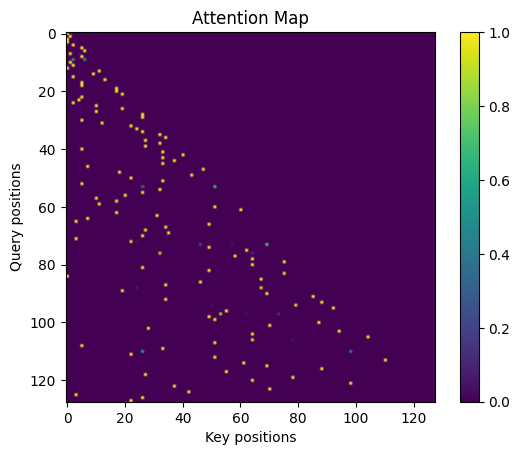

In [21]:
from torch.nn import functional as F
import matplotlib.pyplot as plt

attention = F.softmax(QKt_scaled_masked, dim=-1)

plt.imshow(attention[0].detach().cpu(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key positions")
plt.ylabel("Query positions")
plt.show()

In [22]:
output = attention @ V
output.shape

torch.Size([128, 128, 64])

In [23]:
ffn1 = nn.Linear(embed_size, embed_size * 4)
gelu = nn.GELU()
ffn2 = nn.Linear(embed_size * 4, embed_size)
n_heads = CONFIG["num_heads"]
head_size = embed_size // n_heads
lm_head = nn.Linear(embed_size, head_size)
output_head = lm_head(ffn2(gelu(ffn1(output))))
output_head.shape, output_head

(torch.Size([128, 128, 32]),
 tensor([[[ 1.7304e+00,  9.2521e-01, -2.5229e+00,  ...,  1.1364e+00,
            2.7696e+00,  9.5890e-01],
          [-3.1874e+00,  5.8112e-01, -2.4271e+00,  ..., -1.2078e+00,
           -1.1653e+00, -2.0714e-01],
          [ 1.7304e+00,  9.2521e-01, -2.5229e+00,  ...,  1.1364e+00,
            2.7696e+00,  9.5890e-01],
          ...,
          [-5.0880e-01, -1.1506e+00, -1.2058e+00,  ...,  1.9359e+00,
            1.3197e+00,  1.3992e+00],
          [ 2.3442e+00,  1.5721e+00, -8.2843e-02,  ..., -7.4743e-01,
            1.5912e+00,  1.4533e+00],
          [ 5.8689e-02, -1.9704e+00, -1.0553e+00,  ..., -1.5193e-01,
            2.4891e+00, -2.4591e-01]],
 
         [[ 1.4966e+00,  3.6512e-01, -2.5829e+00,  ...,  2.2531e+00,
            1.8067e+00,  2.3815e+00],
          [-9.3504e-02,  9.2919e-01, -3.2604e+00,  ...,  7.2764e-01,
            2.3536e-01,  8.6390e-01],
          [ 1.4966e+00,  3.6512e-01, -2.5829e+00,  ...,  2.2531e+00,
            1.8067e+00,  2.3

In [24]:
class AttentionHead(nn.Module):
    def __init__(self, head_size):
        nn.Module.__init__(self)
        
        self.head_size = head_size
        embed_size = CONFIG["embed_size"]

        #self.W_q = nn.Linear(embed_size, head_size)
        #self.W_k = nn.Linear(embed_size, head_size)
        #self.W_v = nn.Linear(embed_size, head_size)

        self.W_qkv = nn.Linear(embed_size, head_size * 3)

        seq_len = CONFIG["seq_len"]
        self.register_buffer("tril", torch.tril(torch.ones(seq_len, seq_len)))
        
    def forward(self, x):
        B, T, C = x.shape
        #print("WORKED BTC", B, T, C)

        #Q = self.W_q(x)
        #K = self.W_k(x)
        #V = self.W_v(x)

        QKV = self.W_qkv(x)
        Q, K, V = torch.chunk(QKV, 3, dim=-1)
        
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size))
        #mask = self.tril == 0

        mask = self.tril[:T, :T].to(x.device).bool()   # (T, T)
        #mask = mask.unsqueeze(0)   # (1, 1, T, T) if needed
        #print("MASK", mask.shape)
        #print("QKt_scaled", QKt_scaled.shape)

        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1) # TODO: confirm this
        out = attention @ V

        return out

x, y = sample_batch(1)
x = token_embedding_table(x)
out = AttentionHead(3)(x)
out.shape, out

(torch.Size([1, 128, 3]),
 tensor([[[-6.3414e-01,  6.4017e-02,  6.3085e-02],
          [-5.3169e-01,  2.9092e-01, -3.6500e-02],
          [-8.4195e-01, -8.2287e-04,  1.2117e-01],
          [-7.6148e-01, -9.3187e-02,  9.1408e-02],
          [-5.2415e-01, -2.1215e-01,  1.4452e-01],
          [-4.3384e-01, -1.3388e-01, -4.2722e-02],
          [-5.4725e-01, -1.2842e-01,  3.8348e-02],
          [-4.8440e-01, -3.1035e-02,  2.9901e-02],
          [-4.1683e-01, -3.8146e-02, -1.0198e-03],
          [-5.0520e-01, -1.5937e-01,  1.5632e-01],
          [-4.4544e-01, -2.2089e-01,  1.6364e-01],
          [-3.9669e-01, -2.1234e-01,  1.2935e-01],
          [-3.6211e-01, -2.6317e-01,  1.1388e-01],
          [-3.8236e-01, -1.9976e-01,  1.2800e-01],
          [-4.8102e-01, -1.8264e-01,  1.2073e-01],
          [-4.0206e-01, -1.7099e-01,  7.3102e-02],
          [-4.2414e-01, -1.8111e-01,  1.8064e-01],
          [-4.6055e-01, -1.2634e-01,  1.2883e-01],
          [-3.9953e-01, -2.0566e-01,  1.8227e-01],
     

In [25]:
class MultiHeadAttention(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        n_heads = CONFIG["num_heads"]
        embed_size = CONFIG["embed_size"]
        head_size = embed_size // n_heads
        self.heads = nn.ModuleList([AttentionHead(head_size) for _ in range(n_heads)])
        self.W_o = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        outs = []
        for head in self.heads: # TODO: for here?
            out = head(x)
            outs.append(out)
        mha_out = torch.concat(outs, dim=-1)
        mha_out = self.W_o(mha_out)
        return mha_out

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = MultiHeadAttention()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[-0.1632,  0.0525,  0.2707,  ...,  0.2054,  0.1209, -0.7982],
          [-0.1671,  0.1508,  0.2273,  ...,  0.1545,  0.1504, -0.3467],
          [-0.1412,  0.1449,  0.0161,  ..., -0.0883,  0.2086, -0.4258],
          ...,
          [-0.0323, -0.0336, -0.0709,  ..., -0.2153,  0.2315, -0.1792],
          [-0.0491,  0.0384, -0.0329,  ..., -0.1877,  0.1615, -0.1256],
          [-0.0726, -0.0354, -0.0382,  ..., -0.1957,  0.1881, -0.1654]]],
        grad_fn=<ViewBackward0>))

In [26]:
a = torch.randn((3, 3))
a

tensor([[ 2.0357,  0.1247, -0.8268],
        [-1.6790,  1.6481,  1.8567],
        [ 0.0609,  1.0025,  0.0381]])

In [27]:
tril = torch.tril(torch.ones(3, 3))
tril

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 1., 1.]])

In [28]:
mask = tril == 0
mask

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])

In [29]:
a.masked_fill(mask, float("-inf"))

tensor([[ 2.0357,    -inf,    -inf],
        [-1.6790,  1.6481,    -inf],
        [ 0.0609,  1.0025,  0.0381]])

In [30]:
class FastMultiHeadAttention(nn.Module):
    def __init__(self, n_heads):
        nn.Module.__init__(self)
        embed_size = CONFIG["embed_size"]
        block_size = CONFIG["seq_len"]
        head_size = embed_size // n_heads
        self.n_heads = n_heads
        self.head_size = head_size
        self.W_qkv = nn.Linear(embed_size, embed_size * 3)
        self.W_o = nn.Linear(embed_size, embed_size)
        self.register_buffer("tril", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        QKV = self.W_qkv(x) # (B, T, 3 * embed_size)
        Q, K, V = torch.chunk(QKV, 3, dim=-1)
        Q = Q.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        K = K.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        V = V.view(B, T, self.n_heads, self.head_size).transpose(1, 2)
        Kt = K.transpose(-2, -1)
        QKt = Q @ Kt
        QKt_scaled = QKt / torch.sqrt(torch.tensor(self.head_size)).to(x.device)
        mask = self.tril[:T, :T].bool().unsqueeze(0).unsqueeze(0)
        QKt_masked = QKt_scaled.masked_fill(~mask, float("-inf"))
        attention = F.softmax(QKt_masked, dim=-1)
        V_scaled = attention @ V # (B, n_heads, T, head_size)
        V_scaled_t = V_scaled
        V_scaled_t_realigned = V_scaled_t.transpose(1, 2).contiguous().view(B, T, C)
        output = self.W_o(V_scaled_t_realigned) 
        return output

x, _ = sample_batch(1)
x = token_embedding_table(x)
out = FastMultiHeadAttention(2)(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.3442, -0.1078,  0.4832,  ...,  0.0549,  0.2653,  0.2633],
          [ 0.2341,  0.4190,  0.5995,  ..., -0.2051, -0.1150, -0.1269],
          [ 0.0038,  0.4842,  0.4280,  ..., -0.0982,  0.0233, -0.0141],
          ...,
          [-0.0474,  0.3023,  0.2321,  ..., -0.1119, -0.1576, -0.1320],
          [-0.0445,  0.1869,  0.2156,  ..., -0.1024, -0.1969, -0.1445],
          [-0.1110,  0.2235,  0.1823,  ..., -0.0979, -0.1369, -0.1594]]],
        grad_fn=<ViewBackward0>))

In [31]:
class FeedForward(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        
        embed_size = CONFIG["embed_size"]
        self.ffn1 = nn.Linear(embed_size, embed_size * 4)
        self.gelu = nn.GELU()
        self.ffn2 = nn.Linear(embed_size * 4, embed_size)

    def forward(self, x):
        x = self.ffn1(x)
        x = self.gelu(x)
        x = self.ffn2(x)
        return x

x,y = sample_batch(1)
x = token_embedding_table(x)
mha_out = MultiHeadAttention()(x)
out = FeedForward()(mha_out)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 0.1018,  0.1488, -0.0304,  ...,  0.0563,  0.0225, -0.0247],
          [ 0.1034,  0.0966, -0.0587,  ...,  0.0508,  0.0097, -0.0436],
          [ 0.0184,  0.0393, -0.0163,  ...,  0.0793, -0.0148,  0.0189],
          ...,
          [ 0.0539, -0.0035, -0.0505,  ...,  0.0483,  0.0116,  0.0301],
          [ 0.0427,  0.0173, -0.0341,  ...,  0.0576,  0.0141,  0.0413],
          [ 0.0449,  0.0042, -0.0400,  ...,  0.0653,  0.0079,  0.0310]]],
        grad_fn=<ViewBackward0>))

In [32]:
class Block(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.head = FastMultiHeadAttention(CONFIG["num_heads"])
        self.ffn = FeedForward()
        self.ln1 = nn.LayerNorm(embed_size)
        self.ln2 = nn.LayerNorm(embed_size)

    def forward(self, x):
        if CONFIG["layer_norm_enabled"]:
            x = x + self.head(self.ln1(x))  # Normalize input to attention
        else:
            x = x + self.head(x)
        
        if CONFIG["layer_norm_enabled"]:
            x = x + self.ffn(self.ln2(x))  # Normalize input to FFN
        else:
            x = x + self.ffn(x)
        return x

x, y = sample_batch(1)
x = token_embedding_table(x)
out = Block()(x)
out.shape, out

(torch.Size([1, 128, 64]),
 tensor([[[ 1.8063, -0.7525,  0.6911,  ...,  0.4407, -0.1846,  0.4175],
          [ 2.3528, -0.9049,  2.3739,  ...,  0.7142,  0.2434, -0.9252],
          [ 2.2460, -0.8455,  2.3653,  ...,  0.8263,  0.3167, -0.8513],
          ...,
          [-1.1356, -0.7967,  1.7522,  ..., -1.0503, -0.4605,  1.6989],
          [ 1.3249, -0.5181,  0.4177,  ...,  0.2725, -0.0464,  0.7341],
          [ 0.0399,  0.3953, -0.0208,  ...,  0.4485, -0.3735,  0.1983]]],
        grad_fn=<AddBackward0>))

In [33]:
tokens = encode(pad("hello"))
tokens_t = torch.tensor(tokens)
tokens_t = tokens_t.view(1, seq_len)
tokens_t

tensor([[ 2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
          2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2, 60, 57, 64,
         64, 67]])

In [34]:
class Transformer(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)

        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        self.position_embedding_table = nn.Embedding(CONFIG["seq_len"], embed_size)

        # TODO: seq vs parallel
        self.blocks = nn.ModuleList([Block() for _ in range(CONFIG["num_layers"])])
        self.lm_head = nn.Linear(CONFIG["embed_size"], CONFIG["vocab_size"])
        self.ln_final = nn.LayerNorm(embed_size)

    def forward(self, x):
        B, T = x.shape
        tok_emb = self.token_embedding_table(x)        # (B, T, C)
        pos = torch.arange(T, device=x.device)         # (T,)
        pos_emb = self.position_embedding_table(pos)   # (T, C)
        pos_emb = pos_emb.unsqueeze(0)                 # (1, T, C) -> broadcasts over batch
        x = tok_emb + pos_emb      
        for block in self.blocks: x = block(x)
        if CONFIG["layer_norm_enabled"]: x = self.ln_final(x)
        x = self.lm_head(x)
        return x

    @torch.no_grad()
    def generate(self, text, max_len=20):
        device = next(self.parameters()).device
        seq_len = CONFIG["seq_len"]
        tokens = encode(text)
        tokens_t = torch.tensor(tokens).to(device)
        tokens_t = tokens_t.unsqueeze(0)#view(1, -1)
        output_tokens = []
        while len(output_tokens) < max_len:
            logits = self(tokens_t)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs, num_samples=1)
            idx = idx.squeeze().item()
            tokens.append(idx)
            tokens = tokens[-seq_len:]
            tokens_t = torch.tensor(tokens).to(device).unsqueeze(0)
            #tokens_t = tokens_t.view(1, seq_len)
            output_tokens.append(idx)
        text = decode(output_tokens)
        return text


x, y = sample_batch(1)
out = Transformer()(x)
out.shape, out[0][0]

#text = Transformer().generate("hello")
#print(text)

(torch.Size([1, 128, 89]),
 tensor([-0.3662, -0.0484, -1.8254, -1.0779,  0.0405, -0.1287, -0.2072, -0.2996,
          0.3740, -0.6878,  0.1427, -0.5735,  1.1123,  0.6799,  0.2775,  1.3914,
          0.4750, -0.4343,  0.4492,  0.5930, -0.5673,  0.0364, -1.0913, -0.1730,
         -1.1938,  0.6864,  0.4266, -0.2422,  0.2203, -0.1361, -0.4581, -0.5064,
          0.5445,  0.1522,  0.3952,  0.5158,  0.7208, -0.0023,  0.6316,  0.2953,
          0.3495, -0.7060,  0.9090, -0.3182, -0.6170, -0.4120,  0.6726,  0.6227,
         -0.5774, -0.5600, -0.2331,  0.5677, -0.2236, -0.5612,  0.9449, -0.0117,
          0.3282,  0.1299,  0.2773,  0.5495, -0.0216,  0.3122, -0.8064,  0.9941,
         -1.4562,  0.3757,  0.9785,  0.0263,  0.0742,  0.5068, -0.3492,  0.5582,
          0.8156,  0.0821,  0.2782,  0.1576, -0.4055,  0.2051, -0.0645,  0.3325,
          0.2556,  1.0251,  0.4071,  1.0122, -0.1329,  1.0466,  0.4890, -0.4910,
         -0.1879], grad_fn=<SelectBackward0>))

In [35]:
from torch.utils.data import Dataset

class TrainDataset(Dataset):
    def __init__(self, tokens, seq_len):
        self.tokens = tokens
        self.seq_len = seq_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.seq_len]
        y = self.tokens[idx+1:idx+self.seq_len+1]
        return torch.tensor(x), torch.tensor(y)

    def __len__(self):
        return len(self.tokens) - self.seq_len

tokens = encode(DATASET_TEXT)
train_dataset = TrainDataset(tokens, CONFIG["seq_len"])
x, y = next(iter(train_dataset))
print("x:" + decode(x.tolist())[:10])
print("y:" + decode(y.tolist())[:10])
#print(decode(first_seq))

x:Lord Of Th
y:ord Of The


In [36]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,  # MPS doesn't benefit from >0 workers
    pin_memory=False,  # Not needed for MPS
    drop_last=True  # Ensures consistent batch sizes
)
for x, y in train_loader:
    for i in range(10):
        print("x:" + decode(x[i].tolist())[:10])
        print("y:" + decode(y[i].tolist())[:10])
        print("---")
    break

x:through th
y:hrough the
---
x:a land cal
y: land call
---
x:e far shor
y: far shore
---
x:e it to me
y: it to me!
---
x:rd."
	"Why
y:d."
	"Why?
---
x: ring his 
y:ring his "
---
x: said. "We
y:said. "We 
---
x:s easy to 
y: easy to b
---
x:w it away.
y: it away. 
---
x:Gondor doe
y:ondor does
---


In [37]:
model = Transformer()
#model = torch.compile(model, mode="reduce-overhead") # TODO: no gain on mps?
model.to(DEVICE)
model.train()

Transformer(
  (token_embedding_table): Embedding(89, 64)
  (position_embedding_table): Embedding(128, 64)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (head): FastMultiHeadAttention(
        (W_qkv): Linear(in_features=64, out_features=192, bias=True)
        (W_o): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): FeedForward(
        (ffn1): Linear(in_features=64, out_features=256, bias=True)
        (gelu): GELU(approximate='none')
        (ffn2): Linear(in_features=256, out_features=64, bias=True)
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lm_head): Linear(in_features=64, out_features=89, bias=True)
  (ln_final): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)

In [38]:
# Add this to your training loop to monitor gradients
def get_grad_norm(model):
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    total_norm = total_norm ** (1. / 2)
    return total_norm

# In your training loop, after loss.backward():
grad_norm = get_grad_norm(model)
grad_norm

0.0

In [ ]:
from tqdm import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"])

num_epochs = 10
losses = []
grad_norms = []

for epoch in range(num_epochs):
    batch_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for x, y in batch_bar:
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        logits = model(x)
        logits = logits.permute(0, 2, 1)
        loss = F.cross_entropy(logits, y)
    
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        grad_norm = get_grad_norm(model)
        grad_norms.append(grad_norm)
        batch_bar.set_postfix(loss=f"{loss.item():.4f}", grad_norm=f"{grad_norm:.4f}")

Epoch 4/10:  30%|██▉       | 2326/7821 [03:28<07:51, 11.66it/s, grad_norm=1.3431, loss=1.0913]

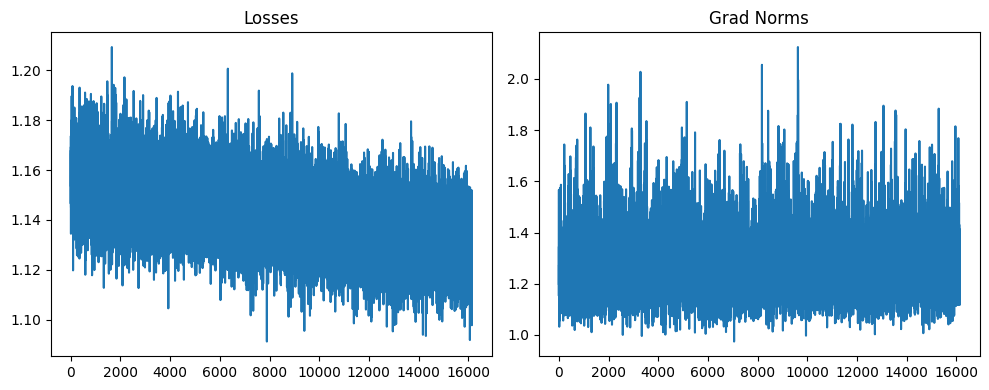

In [43]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left plot
axes[0].plot(losses)
axes[0].set_title("Losses")

# Right plot
axes[1].plot(grad_norms)   # replace with your second dataset
axes[1].set_title("Grad Norms")

plt.tight_layout()
plt.show()

In [45]:
model.eval()
print(model.generate("Frodo picked up the sword", max_len=1024))

s.
	"Nay: death it, he had almost to the round and smiling their voice: a news comfort takes that must killed among into the Misty Tom Cap. Iseing knowledge we know mainly of our coole stop. The glass were faces and the Hotes' hand. The doors of the Bree-back. Some River black and was life that the Black --cools, perhaps reached from lands."
	"Pity!" cried Tom. Through Sauron, sir, exciter! What tell you are it took, as wherever your affaired. He has will be keen up."
	"If I suppose for every than in minds I call to think something," said Frodo. "I knew I bet down as here all the others. I supper), as they they were rememed; trells they would have could believe."
	"But not is a secon
	Too much vanished indir posts; but not he did not so laughed. At last the words of the crack in her ears of a wall of limb.
	"Not know that some of the Mountains ends after realm of the Enemy," he moved himseld, his mind to Gondor. Then a front of old ankway! His sprang picked up would have come on them f

In [ ]:
# Track activations - respect the layer_norm_enabled flag
def track_block_activations(model, x):
    """Track activations at the output of each block."""
    stats = []
    
    model.eval()
    with torch.no_grad():
        # Get embeddings
        x = model.token_embedding_table(x)
        pos = torch.arange(x.size(1), device=x.device)
        pos_emb = model.position_embedding_table(pos).unsqueeze(0)
        x = x + pos_emb
        
        # Track initial state
        stats.append({
            'layer': 'input',
            'mean': x.mean().item(),
            'std': x.std().item(),
            'max_abs': x.abs().max().item()
        })
        
        # Track through each block
        for i, block in enumerate(model.blocks):
            x = block(x)
            stats.append({
                'layer': f'block_{i}',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        
        # Only apply final layer norm if enabled (same as model's forward pass)
        if CONFIG["layer_norm_enabled"]:
            x = model.ln_final(x)
            stats.append({
                'layer': 'final_ln',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
        else:
            # Track the raw output from last block (no normalization)
            stats.append({
                'layer': 'final',
                'mean': x.mean().item(),
                'std': x.std().item(),
                'max_abs': x.abs().max().item()
            })
    
    return stats

# Get a sample batch
x, y = sample_batch(1)
x = x.to(DEVICE)

# Track activations
stats = track_block_activations(model, x)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

layers = [s['layer'] for s in stats]
max_abs = [s['max_abs'] for s in stats]
stds = [s['std'] for s in stats]

# Plot 1: Maximum absolute values (log scale)
axes[0].semilogy(max_abs, marker='o', linewidth=2, markersize=8, color='red')
axes[0].set_title('Maximum Absolute Activation Values', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Layer', fontsize=12)
axes[0].set_ylabel('Max Abs Value (log scale)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(len(layers)))
axes[0].set_xticklabels(layers, rotation=45, ha='right')

# Plot 2: Standard deviation
axes[1].plot(stds, marker='s', linewidth=2, markersize=8, color='blue')
axes[1].set_title('Standard Deviation of Activations', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Layer', fontsize=12)
axes[1].set_ylabel('Standard Deviation', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(len(layers)))
axes[1].set_xticklabels(layers, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary
print("\n" + "="*70)
print("ACTIVATION STATISTICS")
print("="*70)
print(f"{'Layer':<15} {'Mean':>12} {'Std':>12} {'Max Abs':>12}")
print("-"*70)
for s in stats:
    print(f"{s['layer']:<15} {s['mean']:>12.4f} {s['std']:>12.4f} {s['max_abs']:>12.4f}")
print("="*70)

# Calculate growth rate
if len(max_abs) > 1:
    growth_rate = max_abs[-1] / max_abs[0] if max_abs[0] != 0 else float('inf')
    print(f"\nActivation Growth Rate (Final/Initial): {growth_rate:.2f}x")
    print(f"Initial max abs: {max_abs[0]:.4f}")
    print(f"Final max abs: {max_abs[-1]:.4f}")